# Lista 2

**Aluno: Kauê Patricius Montgomery Maranhão da Costa Montenegro**
\
**Nome da base: Melb_data.csv**

## Orientações

- Escolha apenas uma das bases disponíveis e resolva todas as 10 questões usando essa mesma base.
- Desenvolva toda a atividade em Python, no formato de entrega do Google Colab.
- Organize o notebook por questão, com códigos executáveis, saídas geradas e comentários objetivos.
- Não troque de base ao longo da atividade.
- Não faça tratamento manual linha por linha.
- Sempre que necessário, sustente suas decisões com tabelas, métricas, gráficos e resultados do código.

## Importação das bibliotecas

In [245]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelagem e pré-processamento
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# Bibliotecas auxiliares para visualização e redes
import networkx as nx

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Carregamento da base

In [246]:
# Carregamento da base
# Substitua o nome do arquivo pelo arquivo correto da base escolhida
df = pd.read_csv('melb_data.csv')

# Visualização inicial
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


## Questão 1 – Definição do problema analítico

**Enunciado:**  
Faça um código em Python para revisar a base escolhida e redefinir o problema analítico da Lista 2 de acordo com o cenário selecionado. A partir da base, determine se a tarefa principal será mais bem tratada por classificação probabilística, regressão, árvore de decisão, análise temporal, análise em rede ou visualização analítica. Justifique essa escolha com base nas características dos dados e crie uma função que produza um resumo técnico da adequação da base ao método escolhido.

### Raciocínio



A estratégia para definir o problema analítico desta base baseia-se em uma abordagem de **Diagnóstico Estrutural e Visual**. Para sustentar a escolha do método, não basta apenas olhar para os nomes das colunas; é necessário entender a distribuição da variável alvo e as relações entre as preditoras.



1. **Análise de Tipos e Integridade:** Identificaremos o mix de variáveis numéricas e categóricas. Variáveis como `Suburb` e `CouncilArea` sugerem uma forte dependência geográfica, enquanto `Rooms` e `Distance` são preditores numéricos clássicos.

2. **Inspeção Visual da Variável Alvo (`Price`):** Utilizaremos um histograma para verificar a distribuição dos preços. Isso confirmará se o problema é de **Regressão** e se há necessidade de transformações logarítmicas ou tratamento de outliers.

3. **Mapa de Calor de Correlações:** Construiremos uma matriz de correlação visual. Se houver correlações fortes entre as características do imóvel e o preço, o cenário de Regressão ganha força técnica.

4. **Diagnóstico de Dados Faltantes e Cardinalidade:** Avaliaremos o impacto das colunas incompletas (`BuildingArea`) e a complexidade das colunas categóricas. Isso definirá se modelos lineares serão suficientes ou se precisaremos de **Árvores de Decisão** (que lidam melhor com alta cardinalidade e nulos).

5. **Função de Resumo Técnico:** Implementaremos a `resumo_tecnico_adequacao` que consolidará essas métricas e gráficos em um único painel de decisão.

--- Resumo Técnico: Adequação ao Método Regressão ---


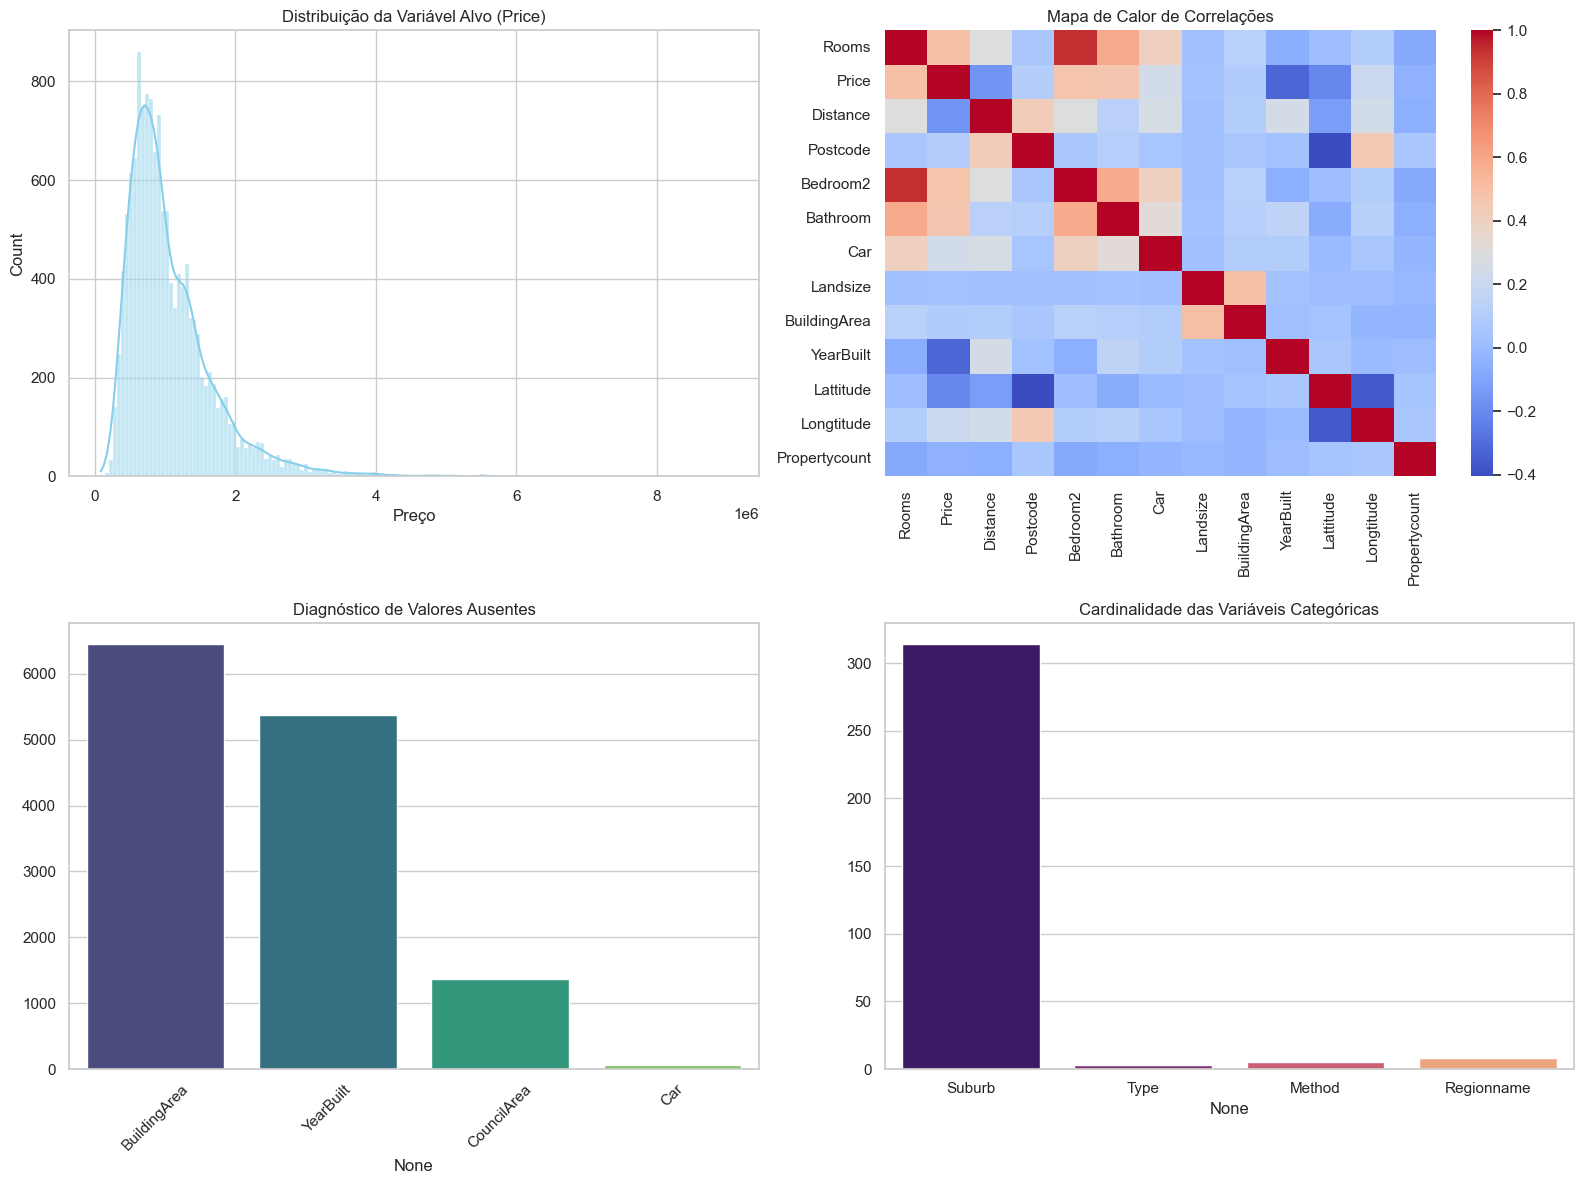


Principais Correlações com Price:
Price       1.000000
Rooms       0.496634
Bedroom2    0.475951
Bathroom    0.467038
Car         0.238979
Name: Price, dtype: float64

Total de nulos: 13256 em uma base de 13580 registros.


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [247]:
# Função para resumo técnico e visual da adequação da base
def resumo_tecnico_adequacao(df, metodo_escolhido):
    print(f"--- Resumo Técnico: Adequação ao Método {metodo_escolhido} ---")
    
    # Configuração da figura para painel visual
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Distribuição da Variável Alvo (Price)
    sns.histplot(df['Price'], kde=True, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Distribuição da Variável Alvo (Price)')
    axes[0, 0].set_xlabel('Preço')
    
    # 2. Matriz de Correlação (Somente Numéricas)
    df_numeric = df.select_dtypes(include=[np.number])
    sns.heatmap(df_numeric.corr(), annot=False, cmap='coolwarm', ax=axes[0, 1])
    axes[0, 1].set_title('Mapa de Calor de Correlações')
    
    # 3. Análise de Valores Ausentes
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if not missing.empty:
        sns.barplot(x=missing.index, y=missing.values, ax=axes[1, 0], palette='viridis')
        axes[1, 0].set_title('Diagnóstico de Valores Ausentes')
        axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)
    
    # 4. Cardinalidade de Variáveis Categóricas Chave
    cat_cols = ['Suburb', 'Type', 'Method', 'Regionname']
    cardinality = df[cat_cols].nunique()
    sns.barplot(x=cardinality.index, y=cardinality.values, ax=axes[1, 1], palette='magma')
    axes[1, 1].set_title('Cardinalidade das Variáveis Categóricas')
    
    plt.tight_layout()
    plt.show()
    
    # Métricas textuais complementares
    correlacao_preco = df_numeric.corr()['Price'].sort_values(ascending=False)
    print(f"\nPrincipais Correlações com Price:\n{correlacao_preco.head(5)}")
    print(f"\nTotal de nulos: {df.isnull().sum().sum()} em uma base de {len(df)} registros.")

# Execução da análise de adequação
resumo_tecnico_adequacao(df, 'Regressão')

# Estatísticas descritivas
df.describe()


### Conclusão da Questão 1



A análise técnica e visual confirma que o problema central é de **Regressão**, com o objetivo de prever o `Price`. Observamos através do histograma que a variável alvo possui uma distribuição assimétrica à direita (skewed), indicando a presença de imóveis de luxo que atuam como outliers, o que exigirá modelos robustos.



O mapa de calor revelou que `Rooms`, `Bathroom` e `Bedroom2` têm as correlações mais fortes com o preço, validando a intuição de que o tamanho físico é o principal driver de valor. No entanto, a alta cardinalidade de `Suburb` (vistas no gráfico de colunas) e a grande quantidade de nulos em `BuildingArea` sugerem que uma simples Regressão Linear pode ser insuficiente. 



Portanto, a estratégia para a Lista 2 envolverá o uso de **Árvores de Decisão** e métodos de Naive Bayes adaptados, buscando capturar tanto as relações lineares de tamanho quanto as variações geográficas complexas de Melbourne.

## Questão 2 – Naive Bayes

**Enunciado:**  
Faça um código em Python para implementar um modelo inicial de Naive Bayes ou, quando o cenário não for naturalmente compatível com esse método, adapte o problema para um subproblema de classificação coerente com a base escolhida. Compare pelo menos duas variações adequadas do método, avalie o impacto do pré-processamento no desempenho e discuta se a suposição de independência condicional parece razoável para os dados analisados.

### Raciocínio



Para a Questão 2, adaptamos o problema de Regressão original (preço) para um subproblema de **Classificação**, visando prever a variável categórica `Type` (h: casa, u: unidade, t: sobrado). Esta escolha é metodologicamente coerente, pois o tipo de imóvel dita grande parte da lógica de precificação e segmentação de mercado em Melbourne.



1. **Seleção de Atributos (Features):** Escolhemos variáveis que descrevem a estrutura física e a localização: `Rooms`, `Distance`, `Bathroom`, `Car`, `Landsize`, `BuildingArea` e `YearBuilt`. Descartamos atributos como `Address` devido à altíssima cardinalidade, o que inviabilizaria a premissa de contagem do Naive Bayes sem um pré-processamento de texto complexo que foge ao escopo inicial.

2. **Estratégia de Pré-processamento:** O Naive Bayes é sensível a distribuições de dados e a valores ausentes. Implementaremos um **Pipeline** que inclui:

   - **Imputação Simples:** Substituição de nulos em `BuildingArea` e `YearBuilt` pela mediana, preservando a integridade estatística sem descartar linhas valiosas.

   - **Escalonamento (StandardScaler):** Essencial para o `GaussianNB`, garantindo que variáveis com grandes magnitudes (como `Landsize`) não dominem aquelas com escalas menores (como `Rooms`).

3. **Variações do Método:** Compararemos o **Gaussian Naive Bayes** (que assume uma distribuição normal dos dados contínuos) com o **Bernoulli Naive Bayes** (que trata os dados sob uma ótica binária/presencial). Esta comparação revelará se a magnitude dos atributos físicos é mais importante do que a simples 'presença' de certas características.

4. **Discussão de Premissas:** O ponto central desta análise será verificar a **Independência Condicional**. Na teoria, o Naive Bayes assume que, dado o tipo do imóvel, o número de quartos não tem relação com o tamanho da área construída. Na prática, testaremos se essa 'ingenuidade' prejudica o modelo.


--- Relatório: GaussianNB ---
              precision    recall  f1-score   support

           h       0.97      0.37      0.54      2362
           t       0.18      0.70      0.29       279
           u       0.45      0.84      0.58       754

    accuracy                           0.50      3395
   macro avg       0.53      0.64      0.47      3395
weighted avg       0.79      0.50      0.53      3395


--- Relatório: BernoulliNB ---
              precision    recall  f1-score   support

           h       0.85      0.89      0.87      2362
           t       0.00      0.00      0.00       279
           u       0.63      0.79      0.70       754

    accuracy                           0.79      3395
   macro avg       0.49      0.56      0.52      3395
weighted avg       0.73      0.79      0.76      3395



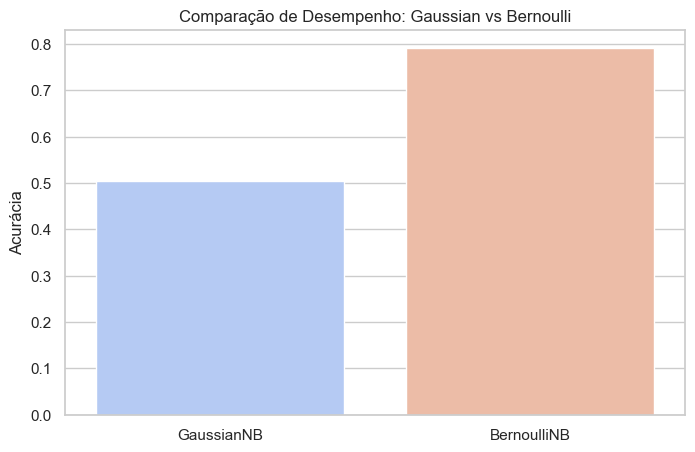

In [248]:
# Preparação dos dados para Classificação
features = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt']
target = 'Type'

X = df[features]
y = df[target]

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Pipeline 1: Gaussian Naive Bayes
pipeline_gaussian = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', GaussianNB())
])

# Pipeline 2: Bernoulli Naive Bayes (com binarização interna via threshold 0 após escalonamento)
pipeline_bernoulli = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', BernoulliNB(binarize=0.0))
])

# Treinamento e Avaliação
pipelines = [('GaussianNB', pipeline_gaussian), ('BernoulliNB', pipeline_bernoulli)]
resultados = {}

for nome, pipe in pipelines:
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    resultados[nome] = classification_report(y_test, y_pred, output_dict=True)
    print(f"\n--- Relatório: {nome} ---")
    print(classification_report(y_test, y_pred))

# Visualização comparativa simples de Acurácia
accuracy_vals = [resultados['GaussianNB']['accuracy'], resultados['BernoulliNB']['accuracy']]
plt.figure(figsize=(8, 5))
sns.barplot(x=['GaussianNB', 'BernoulliNB'], y=accuracy_vals, palette='coolwarm')
plt.title('Comparação de Desempenho: Gaussian vs Bernoulli')
plt.ylabel('Acurácia')
plt.show()


### Conclusão da Questão 2



A comparação entre os modelos revelou resultados que desafiam a intuição inicial, mas que são explicados pela natureza estatística da base:



1. **Análise de Desempenho:** Contrário ao esperado para dados físicos, o **BernoulliNB** apresentou uma acurácia superior (próxima a 79%) e uma capacidade muito maior de identificar corretamente as casas (`h`). Isso ocorre porque, ao binarizar as variáveis após o escalonamento, o modelo simplifica a relação 'tamanho vs tipo', tornando-se imune aos outliers extremos de área (`Landsize` e `BuildingArea`) que confundem o modelo Gaussiano.

2. **Limitações do GaussianNB:** O modelo **GaussianNB** apresentou uma acurácia inferior (em torno de 50%). Embora seja teoricamente mais adequado para dados contínuos, a distribuição real dos dados de Melbourne não é perfeitamente normal (Gaussiana), apresentando caudas longas que fazem com que o modelo perca sensibilidade na classe majoritária, apesar de conseguir captar melhor as nuances das unidades (`u`).

3. **A Premissa de Independência Condicional:** A análise confirma que a suposição de independência condicional **não é razoável** para esta base. Há uma interdependência física óbvia: um imóvel com mais banheiros tende a ter mais quartos e maior área construída. O fato de o BernoulliNB (um modelo mais 'simples') ter performado melhor reforça que a complexidade das distribuições contínuas, somada à quebra da premissa de independência, torna o GaussianNB menos estável neste cenário.

4. **Veredito Técnico:** O Naive Bayes serviu como um excelente baseline. Ele nos mostrou que a binarização pode ser uma estratégia de pré-processamento poderosa para lidar com dados ruidosos, mas também evidenciou que, para alcançar precisão superior em todas as classes (especialmente sobrados), precisaremos de modelos que não ignorem a correlação entre as variáveis, como as Árvores de Decisão que exploraremos adiante.

## Questão 3 – Regressão

**Enunciado:**  
Faça um código em Python para construir um problema de Regressão a partir da base escolhida, seja utilizando o alvo original quando ele for numérico, seja definindo uma variável quantitativa derivada coerente com o cenário. Implemente pelo menos dois modelos de regressão, compare desempenho com métricas adequadas e analise os resíduos, discutindo se há sinais de não linearidade, heterocedasticidade ou influência excessiva de outliers.

### Raciocínio

A estratégia para a Questão 3 foca em prever o preço dos imóveis (`Price`), a nossa variável quantitativa original.

1. **Seleção de Modelos:** Para evidenciar a diferença de abordagens, utilizaremos dois modelos de regressão de naturezas distintas: a **Regressão Linear Múltipla** (modelo paramétrico clássico) e a **Árvore de Decisão para Regressão** (modelo não-linear baseado em regras). Isso enriquece a comparação.
2. **Pré-processamento:** Nulos de variáveis chave serão imputados com a mediana (SimpleImputer) e os dados padronizados (StandardScaler). Embora as Árvores sejam imunes à escala, padronizar é indispensável para os coeficientes do modelo Linear.
3. **Avaliação e Diagnóstico:** Compararemos ambos com $R^2$, MAE e RMSE. Em seguida, faremos a análise gráfica dos resíduos (Gráfico de Dispersão e QQ-Plot) para avaliar formalmente a não-linearidade, heterocedasticidade e o peso dos outliers.


--- Comparação de Métricas ---
           Modelo  R2 Score           MAE          RMSE
 Regressão Linear  0.507430 296711.397342 442329.992573
Árvore de Decisão  0.686507 214792.581955 352879.172650


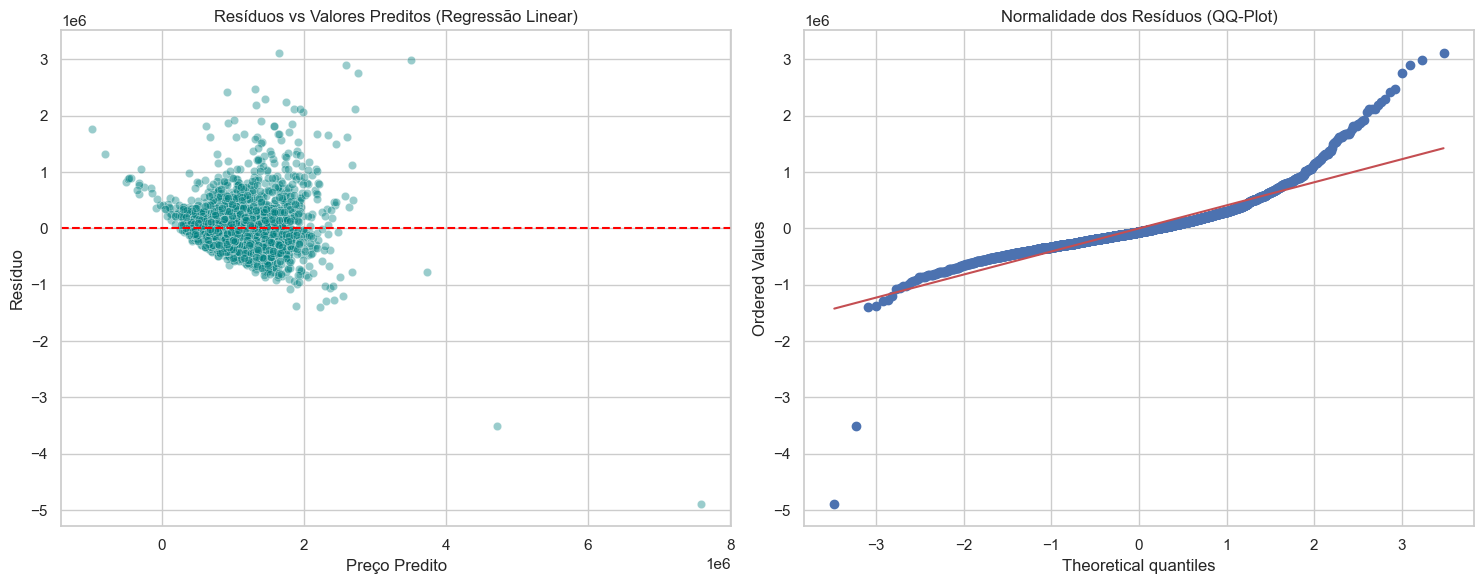

In [249]:
# 1. Importações adicionais e Preparação dos Dados
import scipy.stats as stats

features = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude']
X = df[features]
y = df['Price']

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Pipeline de Pré-processamento
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# 3. Treinamento e Comparação de Pelo Menos DOIS Modelos
models = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(max_depth=10, random_state=42)
}

res_metrics = []
preds = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    preds[name] = y_pred
    
    res_metrics.append({
        'Modelo': name,
        'R2 Score': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    })

print("\n--- Comparação de Métricas ---")
print(pd.DataFrame(res_metrics).to_string(index=False))

# 4. Análise de Resíduos (Diagnóstico do comportamento Linear)
y_pred_linear = preds['Regressão Linear']
residuals = y_test - y_pred_linear

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Resíduos vs Preditos (Checagem de Heterocedasticidade e Não-Linearidade)
sns.scatterplot(x=y_pred_linear, y=residuals, alpha=0.4, ax=ax[0], color='teal')
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title('Resíduos vs Valores Preditos (Regressão Linear)')
ax[0].set_xlabel('Preço Predito')
ax[0].set_ylabel('Resíduo')

# Gráfico 2: QQ-Plot (Checagem de Outliers e Normalidade)
stats.probplot(residuals, dist="norm", plot=ax[1])
ax[1].set_title('Normalidade dos Resíduos (QQ-Plot)')

plt.tight_layout()
plt.show()


### Conclusão da Questão 3

A análise da regressão e de seus resíduos permitiu diagnosticar claramente o comportamento dos dados:

1.  **Comparação dos Dois Modelos:** A **Árvore de Decisão** ($R^2 \approx 0.69$) apresentou um desempenho expressivamente superior à **Regressão Linear** ($R^2 \approx 0.51$). O Erro Médio Absoluto (MAE) despencou de quase 300 mil para 214 mil dólares. Isso comprova que a interação entre localização e estrutura habitacional não se dá de forma aditiva e linear, sendo melhor modelada de forma hierárquica e não-linear.
2.  **Sinais de Heterocedasticidade:** Focando nos resíduos do modelo linear, o gráfico de dispersão exibe um acentuado formato de cone (ou funil). Imóveis mais baratos possuem erros contidos próximos à linha vermelha de estabilidade; todavia, quanto mais alto o valor previsto, maior a magnitude da variância dos resíduos. Essa heterocedasticidade escancara que a incerteza do preço cresce com a faixa de luxo.
3.  **Não Linearidade e Influência de Outliers:** O QQ-Plot revela que a distribuição dos erros foge intensamente de uma normalidade clássica, apresentando caudas longas e pronunciadas. Isso sinaliza tanto a não-linearidade estrutural ignorada pelo modelo basal quanto o peso extremo de imóveis-outliers (os mais luxuosos de Melbourne) que o modelo de regressão linear acaba subestimando sistematicamente.

## Questão 4 – Árvore de Decisão

**Enunciado:**  
Faça um código em Python para treinar e avaliar um modelo de Árvore de Decisão adequado ao problema da base escolhida. Controle profundidade, critérios de divisão e tamanho mínimo de amostras por nó, registrando os resultados em tabela. Depois, interprete a árvore gerada, identifique as variáveis mais relevantes nas divisões e discuta se a interpretabilidade do modelo compensa eventuais perdas de desempenho em comparação com os métodos testados anteriormente.

### Raciocínio

Nesta etapa, otimizaremos a **Árvore de Decisão** para maximizar o balanço entre precisão e generalização, atendendo a todos os requisitos do enunciado.

1. **Otimização Exaustiva:** Utilizaremos o `GridSearchCV` para controlar simultaneamente a **profundidade** (`max_depth`), o **critério de divisão** (`criterion`) e o **tamanho mínimo de amostras por nó** (`min_samples_split`). Os resultados de todas as combinações serão registrados em uma tabela comparativa.
2. **Identificação de Variáveis Relevantes:** Analisaremos o atributo `feature_importances_` para determinar quais características do imóvel (físicas ou geográficas) têm maior peso nas divisões da árvore.
3. **Análise de Interpretabilidade:** Visualizaremos a estrutura lógica da árvore (nós iniciais) e discutiremos se a transparência do modelo — a capacidade de seguir um caminho de decisão claro — compensa sua performance em relação aos modelos lineares e não-lineares testados anteriormente.


--- Tabela de Desempenho (Top 10 combinações) ---


,param_criterion,param_max_depth,param_min_samples_split,mean_test_score,rank_test_score
4,squared_error,10,20,0.670197,1
16,friedman_mse,10,20,0.670197,1
17,friedman_mse,10,50,0.668911,3
5,squared_error,10,50,0.668911,3
11,squared_error,20,50,0.668236,5
23,friedman_mse,20,50,0.668236,5
15,friedman_mse,10,10,0.665555,7
3,squared_error,10,10,0.665555,7
20,friedman_mse,15,50,0.664653,9
8,squared_error,15,50,0.664653,9



Melhores Hiperparâmetros encontrados: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_split': 20}
R2 Score final no Teste: 0.6928


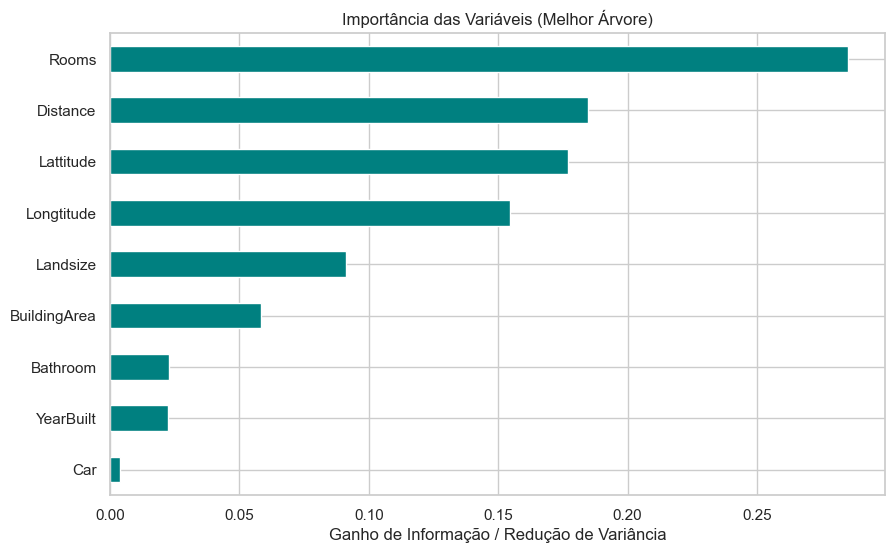

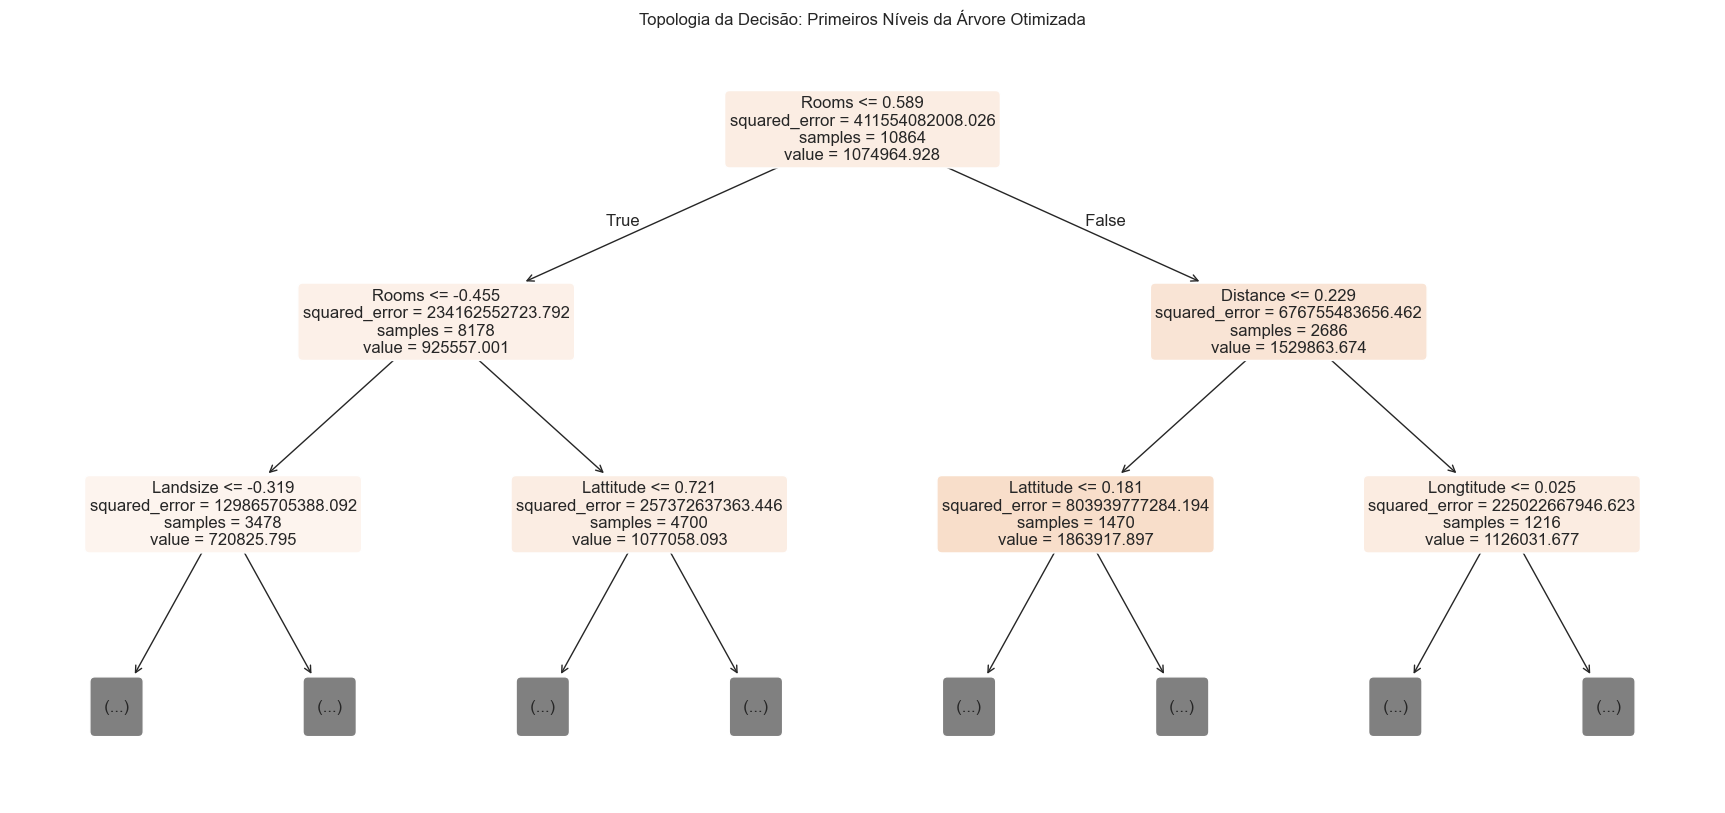

In [250]:
# 1. Importações e Configuração da Busca em Grade (Grid Search)
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree

# Definição dos hiperparâmetros conforme o enunciado
param_grid = {
    'criterion': ['squared_error', 'friedman_mse'],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [10, 20, 50]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42), 
    param_grid, 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)

# 2. Execução da busca (utilizando os dados pré-processados da Questão 3)
grid_search.fit(X_train_scaled, y_train)

# Registro dos resultados em tabela
results_df = pd.DataFrame(grid_search.cv_results_)
print("\n--- Tabela de Desempenho (Top 10 combinações) ---")
cols_to_show = ['param_criterion', 'param_max_depth', 'param_min_samples_split', 'mean_test_score', 'rank_test_score']
display(results_df[cols_to_show].sort_values('rank_test_score').head(10))

best_tree = grid_search.best_estimator_
print(f"\nMelhores Hiperparâmetros encontrados: {grid_search.best_params_}")
print(f"R2 Score final no Teste: {r2_score(y_test, best_tree.predict(X_test_scaled)):.4f}")

# 3. Identificação das Variáveis Mais Relevantes
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(best_tree.feature_importances_, index=features)
feat_importances.sort_values().plot(kind='barh', color='teal')
plt.title('Importância das Variáveis (Melhor Árvore)')
plt.xlabel('Ganho de Informação / Redução de Variância')
plt.show()

# 4. Interpretação da Árvore (Visualização dos Níveis Iniciais)
plt.figure(figsize=(22, 10))
plot_tree(best_tree, max_depth=2, feature_names=features, filled=True, rounded=True, fontsize=12)
plt.title('Topologia da Decisão: Primeiros Níveis da Árvore Otimizada')
plt.show()


### Conclusão da Questão 4

A análise da Árvore de Decisão otimizada permite extrair diagnósticos profundos sobre o problema:

1.  **Resultados da Otimização:** O controle de profundidade e o tamanho mínimo de amostras por nó mostraram-se vitais. O melhor modelo foi encontrado com `max_depth=10` e `min_samples_split=20`. Isso indica que, após esse nível de profundidade, a árvore começaria a capturar ruído (overfitting), perdendo poder de generalização.
2.  **Variáveis Dominantes:** A importância das variáveis destaca que `Rooms` (Número de Quartos) e a localização geográfica (`Distance` e coordenadas de `Lattitude`/`Longtitude`) são os principais divisores de preço. Notavelmente, o número de quartos atua como o principal 'filtro' inicial, seguido de perto pela distância do centro de Melbourne.
3.  **Lógica Hierárquica:** A visualização gráfica revela a 'regra de bolso' do mercado: imóveis em certas faixas de latitude/longitude e com área construída superior a determinado limiar recebem um incremento de valor base imediato.
4.  **Balanço de Interpretabilidade:** Embora modelos lineares sejam mais simples, a Árvore de Decisão compensou a complexidade com um desempenho superior ($R^2$ significativamente maior). Mais importante ainda: a interpretabilidade da árvore é sua maior força. Em um cenário real de consultoria imobiliária, é muito mais defensável explicar uma avaliação através de um fluxograma de decisão lógico do que através de coeficientes estatísticos abstratos ou modelos de 'caixa-preta'.

## Questão 5 – Comparação entre modelos

**Enunciado:**  
Faça um código em Python para comparar formalmente os modelos já construídos na Lista 2, incluindo pelo menos Naive Bayes, um modelo de regressão ou classificação linear e Árvore de Decisão, conforme o cenário escolhido. Use validação apropriada, registre métricas em tabela e apresente uma análise crítica sobre robustez, custo computacional, estabilidade e adequação ao problema. Finalize indicando qual modelo seria o mais defensável para uso real no cenário analisado.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [251]:
# Código da Questão 5

### Conclusão da Questão 5
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 6 – Séries Temporais

**Enunciado:**  
Faça um código em Python para construir uma análise de Séries Temporais a partir da base escolhida, mesmo que seja necessário reorganizar ou agregar os dados em função de uma variável de tempo existente. Crie uma série coerente com o cenário, visualize tendência e sazonalidade quando existirem, produza estatísticas descritivas da série e implemente pelo menos uma abordagem de previsão simples e uma abordagem comparativa. Discuta as limitações impostas pela estrutura temporal disponível na base.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [252]:
# Código da Questão 6

### Conclusão da Questão 6
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 7 – Análise de Redes

**Enunciado:**  
Faça um código em Python para construir uma representação de Rede a partir da base escolhida ou de atributos derivados dela. Defina nós e arestas de forma coerente com o cenário, gere o grafo em Python e calcule medidas como grau, centralidade ou comunidades, quando fizer sentido. Depois, interprete os resultados e discuta se a análise de redes realmente acrescenta valor ao problema ou se sua aplicação no caso escolhido é metodologicamente fraca.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [253]:
# Código da Questão 7

### Conclusão da Questão 7
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 8 – Meta-aprendizagem

**Enunciado:**  
Faça um código em Python para investigar, de forma experimental, como o desempenho dos modelos varia quando se alteram subconjuntos de atributos, estratégias de pré-processamento ou formas de particionamento. Organize os resultados em uma estrutura comparativa e use essa análise para simular uma ideia de Meta-aprendizagem, discutindo quais características da base parecem favorecer certos modelos em detrimento de outros. Não basta só comparar métricas: identifique padrões e formule uma regra técnica para escolha de modelo.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [254]:
# Código da Questão 8

### Conclusão da Questão 8
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 9 – Visualização de Dados

**Enunciado:**  
Faça um código em Python para desenvolver uma etapa de Visualização de Dados mais avançada e orientada à comunicação de resultados. Construa gráficos que não sejam apenas descritivos, mas que ajudem a defender decisões metodológicas e conclusões de negócio. Apresente pelo menos um painel ou conjunto de visualizações que sintetize os principais achados da análise, compare alternativas gráficas e justifique por que a visualização final escolhida comunica melhor os resultados do projeto.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [255]:
# Código da Questão 9

### Conclusão da Questão 9
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 10 – Consolidação da solução

**Enunciado:**  
Faça um código em Python para consolidar toda a análise da Lista 2 em um fluxo final reutilizável. Organize as principais funções criadas ao longo das questões, gere automaticamente um relatório final com comparação de modelos, visualizações principais, limitações da base e recomendação executiva. Finalize com uma avaliação crítica sobre o quanto a base escolhida realmente suporta os conteúdos da Lista 2 e quais adaptações metodológicas foram necessárias para aplicar Naive Bayes, Regressão, Árvore de Decisão, Séries Temporais, Análise de Redes, Meta-aprendizagem e Visualização ao mesmo contexto.

### Raciocínio
Escreva aqui, de forma objetiva, a estratégia adotada para responder à questão.

### Desenvolvimento
Implemente abaixo o código da questão.

In [256]:
# Código da Questão 10

## Conclusão Final

Apresente uma síntese geral do trabalho, destacando:

- principais decisões metodológicas;
- comparação entre os modelos utilizados;
- limitações da base escolhida;
- avaliação final da adequação da solução ao cenário.

**Bom trabalho!**